### Download dataset

In [61]:
import kagglehub
from pathlib import Path

path = Path(kagglehub.dataset_download("irkaal/foodcom-recipes-and-reviews"))
print(path)
for f in path.iterdir():
    print(f.name, f"{f.stat().st_size / 1e6:.1f} MB")

/Users/nico/.cache/kagglehub/datasets/irkaal/foodcom-recipes-and-reviews/versions/2
reviews.csv 496.1 MB
recipes.csv 704.2 MB
recipes.parquet 178.7 MB
reviews.parquet 173.8 MB


### Load datasets

In [62]:
import pandas as pd

recipes = pd.read_parquet(path / "recipes.parquet")
reviews = pd.read_parquet(path / "reviews.parquet")

### Schema & sample rows

In [63]:
recipes.head()

,RecipeId,Name,AuthorId,AuthorName,CookTime,PrepTime,TotalTime,DatePublished,Description,Images,...,SaturatedFatContent,CholesterolContent,SodiumContent,CarbohydrateContent,FiberContent,SugarContent,ProteinContent,RecipeServings,RecipeYield,RecipeInstructions
0,38.0,Low-Fat Berry Blue Frozen Dessert,1533,Dancer,PT24H,PT45M,PT24H45M,1999-08-09 21:46:00+00:00,Make and share this Low-Fat Berry Blue Frozen ...,[https://img.sndimg.com/food/image/upload/w_55...,...,1.3,8.0,29.8,37.1,3.6,30.2,3.2,4.0,NaN,"[Toss 2 cups berries with sugar., Let stand fo..."
1,39.0,Biryani,1567,elly9812,PT25M,PT4H,PT4H25M,1999-08-29 13:12:00+00:00,Make and share this Biryani recipe from Food.com.,[https://img.sndimg.com/food/image/upload/w_55...,...,16.6,372.8,368.4,84.4,9.0,20.4,63.4,6.0,NaN,[Soak saffron in warm milk for 5 minutes and p...
2,40.0,Best Lemonade,1566,Stephen Little,PT5M,PT30M,PT35M,1999-09-05 19:52:00+00:00,This is from one of my first Good House Keepi...,[https://img.sndimg.com/food/image/upload/w_55...,...,0.0,0.0,1.8,81.5,0.4,77.2,0.3,4.0,NaN,"[Into a 1 quart Jar with tight fitting lid, pu..."
3,41.0,Carina's Tofu-Vegetable Kebabs,1586,Cyclopz,PT20M,PT24H,PT24H20M,1999-09-03 14:54:00+00:00,This dish is best prepared a day in advance to...,[https://img.sndimg.com/food/image/upload/w_55...,...,3.8,0.0,1558.6,64.2,17.3,32.1,29.3,2.0,4 kebabs,"[Drain the tofu, carefully squeezing out exces..."
4,42.0,Cabbage Soup,1538,Duckie067,PT30M,PT20M,PT50M,1999-09-19 06:19:00+00:00,Make and share this Cabbage Soup recipe from F...,[https://img.sndimg.com/food/image/upload/w_55...,...,0.1,0.0,959.3,25.1,4.8,17.7,4.3,4.0,NaN,"[Mix everything together and bring to a boil.,..."


In [64]:
recipes.info()

<class 'pandas.DataFrame'>
RangeIndex: 522517 entries, 0 to 522516
Data columns (total 28 columns):
 #   Column                      Non-Null Count   Dtype              
---  ------                      --------------   -----              
 0   RecipeId                    522517 non-null  float64            
 1   Name                        522517 non-null  str                
 2   AuthorId                    522517 non-null  int32              
 3   AuthorName                  522517 non-null  str                
 4   CookTime                    439972 non-null  str                
 5   PrepTime                    522517 non-null  str                
 6   TotalTime                   522517 non-null  str                
 7   DatePublished               522517 non-null  datetime64[us, UTC]
 8   Description                 522512 non-null  str                
 9   Images                      522516 non-null  object             
 10  RecipeCategory              521766 non-null  str       

In [65]:
reviews.head()

,ReviewId,RecipeId,AuthorId,AuthorName,Rating,Review,DateSubmitted,DateModified
0,2,992,2008,gayg msft,5,better than any you can get at a restaurant!,2000-01-25 21:44:00+00:00,2000-01-25 21:44:00+00:00
1,7,4384,1634,Bill Hilbrich,4,"I cut back on the mayo, and made up the differ...",2001-10-17 16:49:59+00:00,2001-10-17 16:49:59+00:00
2,9,4523,2046,Gay Gilmore ckpt,2,i think i did something wrong because i could ...,2000-02-25 09:00:00+00:00,2000-02-25 09:00:00+00:00
3,13,7435,1773,Malarkey Test,5,easily the best i have ever had. juicy flavor...,2000-03-13 21:15:00+00:00,2000-03-13 21:15:00+00:00
4,14,44,2085,Tony Small,5,An excellent dish.,2000-03-28 12:51:00+00:00,2000-03-28 12:51:00+00:00


### Data quality

In [66]:
miss = recipes.isna().mean().sort_values()

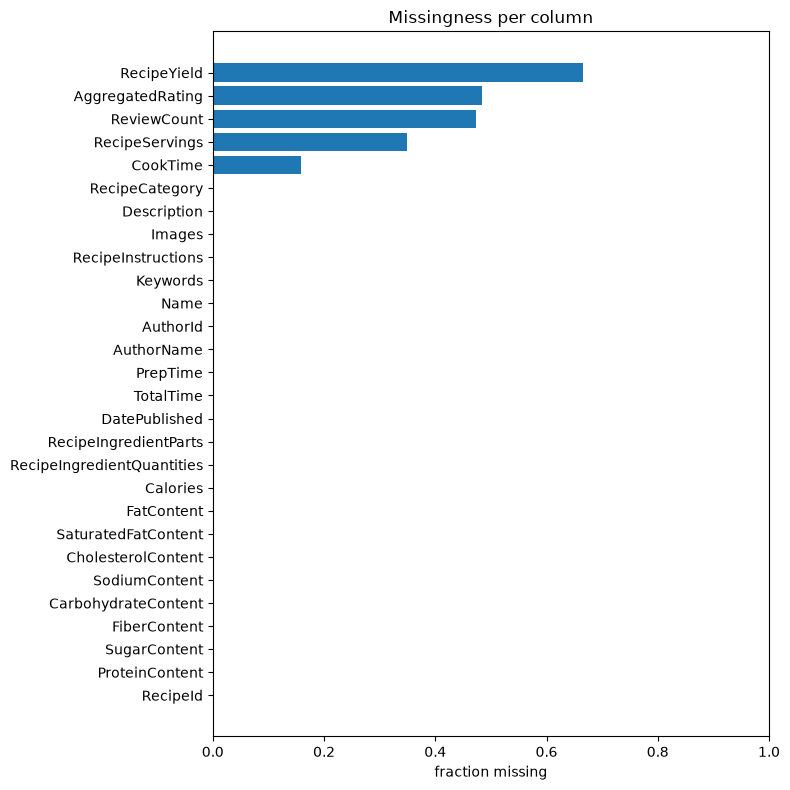

In [67]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(miss.index, miss.values)
ax.set_xlabel("fraction missing")
ax.set_title("Missingness per column")
ax.set_xlim(0, 1)
fig.tight_layout()

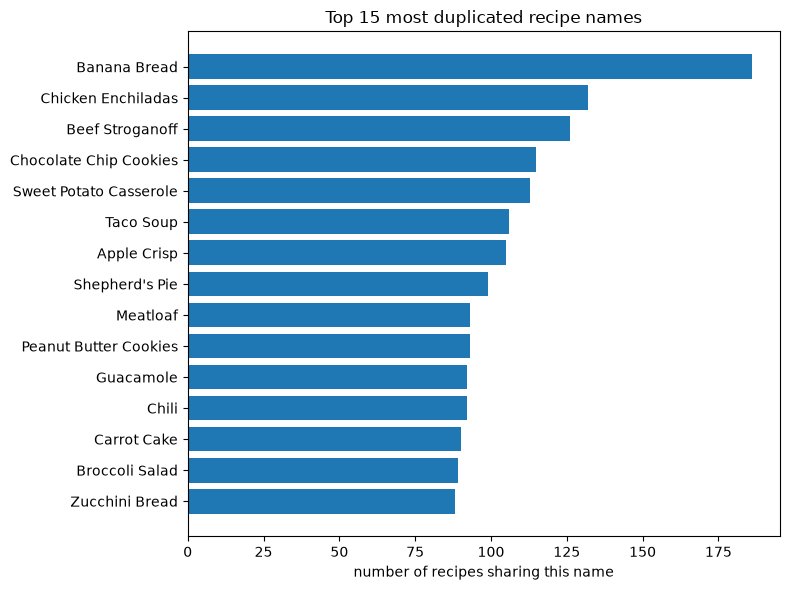

In [68]:
top_names = recipes['Name'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top_names.index, top_names.values)
ax.invert_yaxis()
ax.set_xlabel("number of recipes sharing this name")
ax.set_title("Top 15 most duplicated recipe names")
fig.tight_layout()

**Takeaways:** several columns have large gaps, so the embedding document leans on the
always-present fields (`Name`, `RecipeInstructions`). Recipe *names* repeat heavily (legit
variants) → **dedup on the full text, never on the name** (→ notebook 2).

### Nutrition distributions

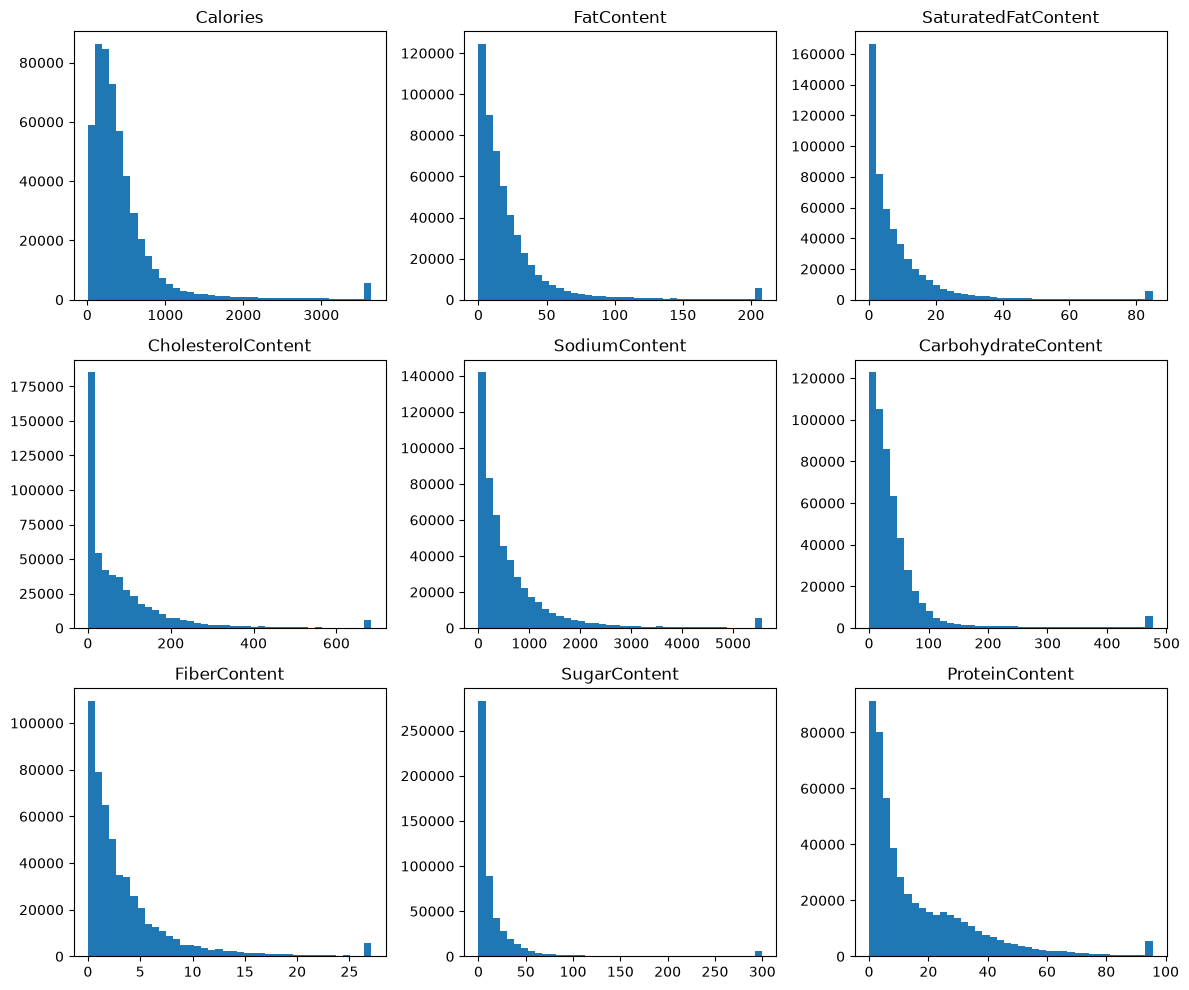

In [69]:
nutrition_cols = [
    "Calories", "FatContent", "SaturatedFatContent",
    "CholesterolContent", "SodiumContent", "CarbohydrateContent",
    "FiberContent", "SugarContent", "ProteinContent",
]

fig, axes = plt.subplots(3, 3, figsize=(12, 10))

for col, ax in zip(nutrition_cols, axes.flat):
    lo, hi = recipes[col].quantile([0.01, 0.99])
    ax.hist(recipes[col].clip(lo, hi), bins=40)
    ax.set_title(col)

fig.tight_layout()

**Takeaway:** nutrition fields are heavily right-skewed with extreme outliers (hence the
p1–p99 clipping just to see the shape). Fine as metadata for filters (e.g. "under 500
kcal"), but raw values need clipping/care before any modelling.

### Categories, keywords & ingredients

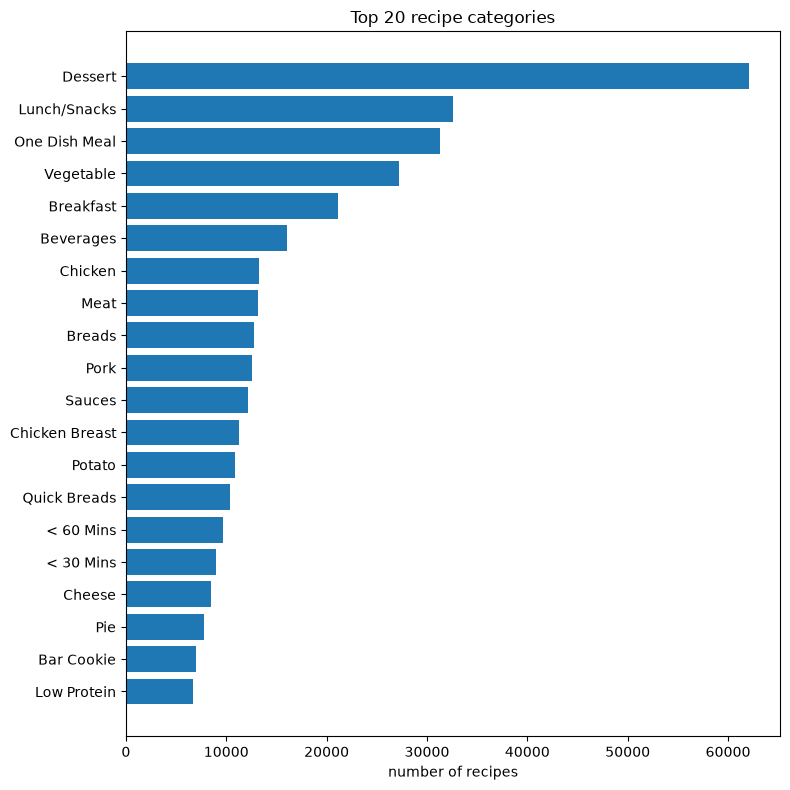

In [70]:
top_categories = recipes['RecipeCategory'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(top_categories.index, top_categories.values)
ax.invert_yaxis()
ax.set_xlabel("number of recipes")
ax.set_title("Top 20 recipe categories")
fig.tight_layout()

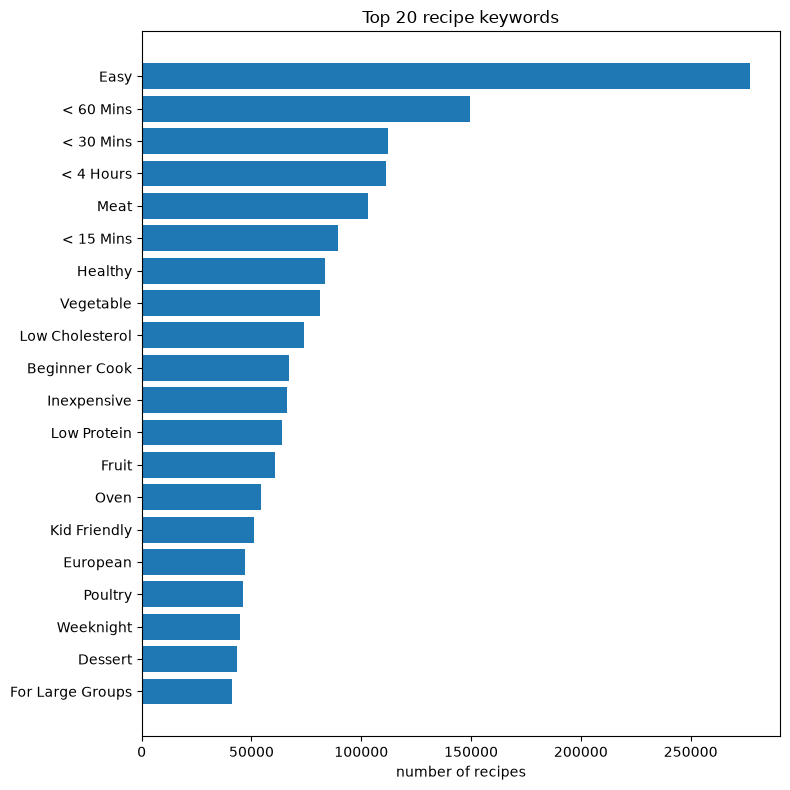

In [71]:
top_keywords = recipes['Keywords'].explode().value_counts().head(20)

fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(top_keywords.index, top_keywords.values)
ax.invert_yaxis()
ax.set_xlabel("number of recipes")
ax.set_title("Top 20 recipe keywords")
fig.tight_layout()

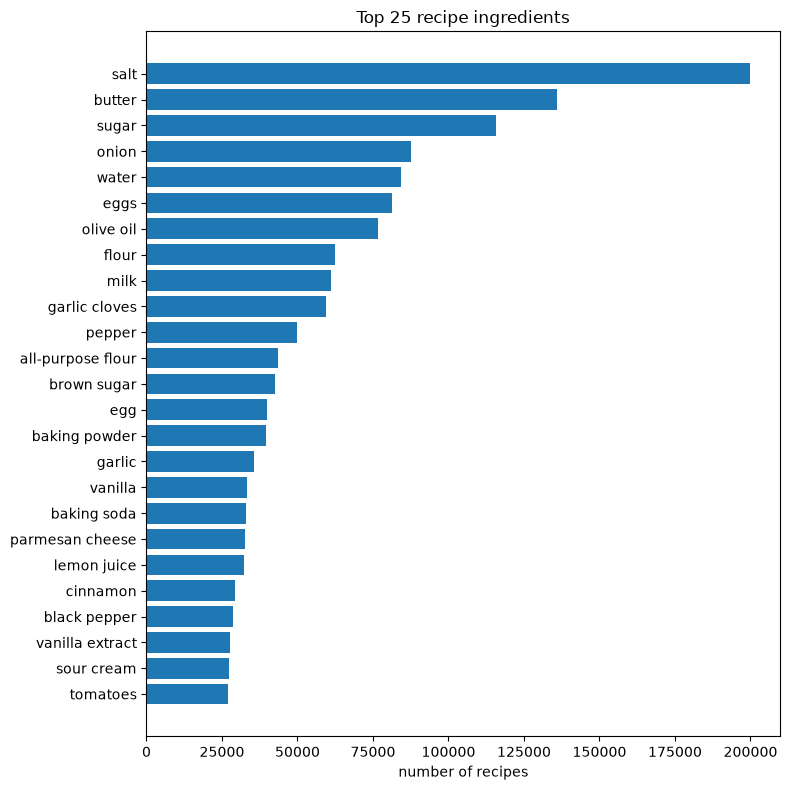

In [72]:
top_ingredients = recipes['RecipeIngredientParts'].explode().value_counts().head(25)

fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(top_ingredients.index, top_ingredients.values)
ax.invert_yaxis()
ax.set_xlabel("number of recipes")
ax.set_title("Top 25 recipe ingredients")
fig.tight_layout()

**Takeaway:** a few categories/keywords dominate, with a long tail of rare ones. Relevant
for sampling (**stratify by category** so rare ones survive the dev sample → notebook 2)
and as candidate metadata for structured filters.

### Nutrition correlations

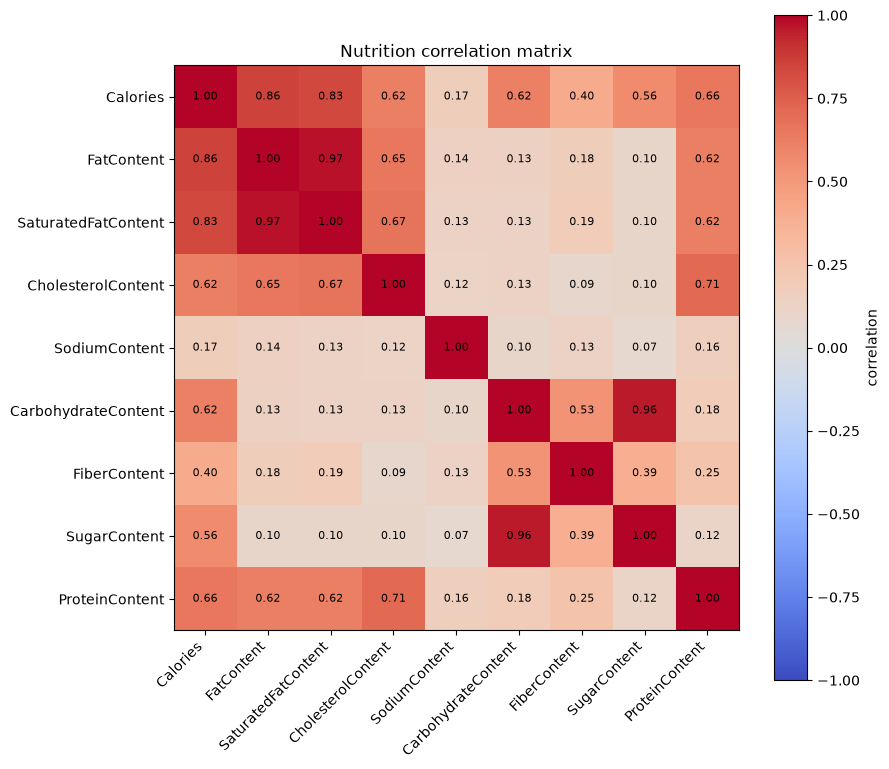

In [73]:
corr = recipes[nutrition_cols].corr()

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(corr)))
ax.set_yticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)

for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

fig.colorbar(im, ax=ax, label="correlation")
ax.set_title("Nutrition correlation matrix")
fig.tight_layout()

**Takeaway:** calories correlate strongly with fat/carbs/protein (as expected), so the
nutrition fields are partly redundant — calories alone is a decent single proxy if we ever
need one axis for filtering or ranking.

### Reviews exploration

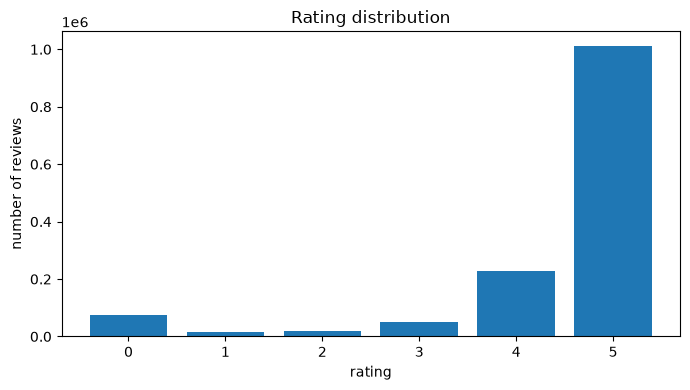

In [74]:
rating_counts = reviews['Rating'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(rating_counts.index.astype(int).astype(str), rating_counts.values)
ax.set_xlabel("rating")
ax.set_ylabel("number of reviews")
ax.set_title("Rating distribution")
fig.tight_layout()

share of 0-ratings:   5.4%
mean rating incl. 0:  4.408
mean rating excl. 0:  4.661


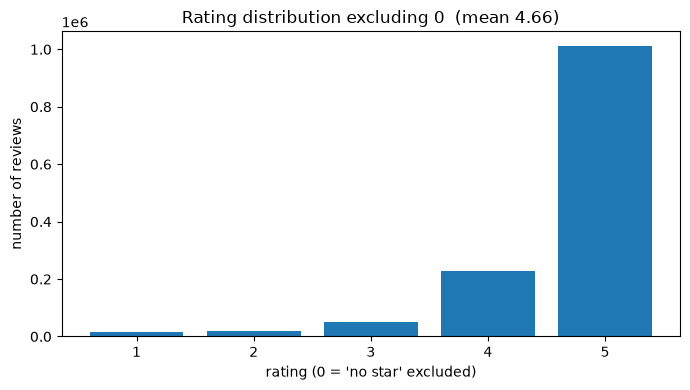

In [77]:
nonzero = reviews.loc[reviews['Rating'] > 0, 'Rating']
print(f"share of 0-ratings:   {(reviews['Rating'] == 0).mean():.1%}")
print(f"mean rating incl. 0:  {reviews['Rating'].mean():.3f}")
print(f"mean rating excl. 0:  {nonzero.mean():.3f}")

vc = nonzero.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(vc.index.astype(int).astype(str), vc.values)
ax.set_xlabel("rating (0 = 'no star' excluded)")
ax.set_ylabel("number of reviews")
ax.set_title(f"Rating distribution excluding 0  (mean {nonzero.mean():.2f})")
fig.tight_layout()

recipes total:           522,517
recipes with >=1 review: 271,674 (52.0%)
recipes with 0 reviews:  250,843 (48.0%)
median reviews / reviewed recipe: 2
max reviews on one recipe:        2,892


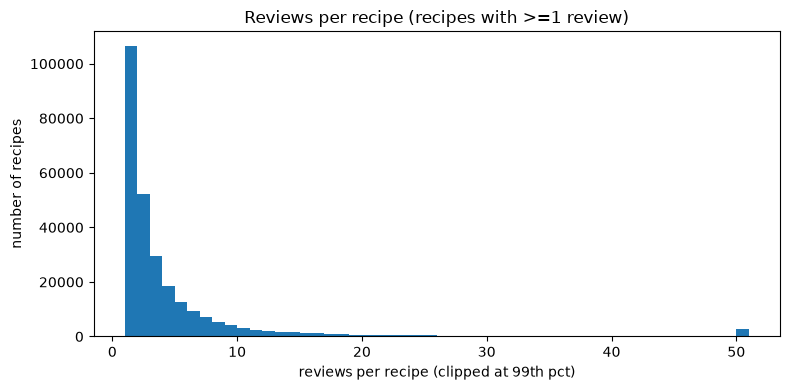

In [75]:
reviews_per_recipe = reviews['RecipeId'].value_counts()
n_recipes = len(recipes)
n_with_reviews = recipes['RecipeId'].isin(reviews_per_recipe.index).sum()

print(f"recipes total:           {n_recipes:,}")
print(f"recipes with >=1 review: {n_with_reviews:,} ({n_with_reviews / n_recipes:.1%})")
print(f"recipes with 0 reviews:  {n_recipes - n_with_reviews:,} ({1 - n_with_reviews / n_recipes:.1%})")
print(f"median reviews / reviewed recipe: {reviews_per_recipe.median():.0f}")
print(f"max reviews on one recipe:        {reviews_per_recipe.max():,}")

hi = reviews_per_recipe.quantile(0.99)
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(reviews_per_recipe.clip(upper=hi), bins=50)
ax.set_xlabel("reviews per recipe (clipped at 99th pct)")
ax.set_ylabel("number of recipes")
ax.set_title("Reviews per recipe (recipes with >=1 review)")
fig.tight_layout()

recipes with reviews:              271,674
ReviewCount == computed count:     91.8%
AggregatedRating ~= computed mean: 66.4%


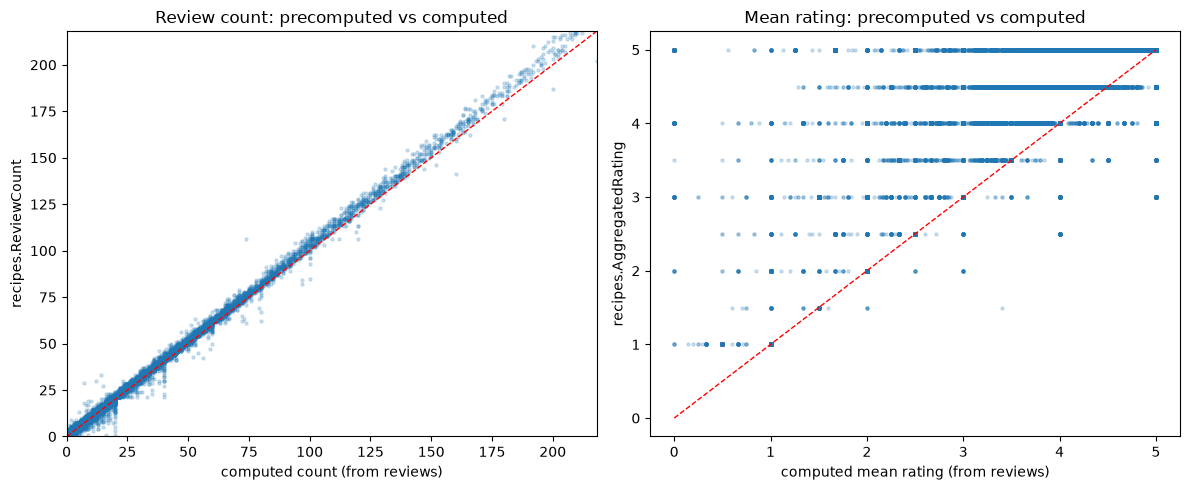

In [76]:
import numpy as np

computed = reviews.groupby('RecipeId')['Rating'].agg(computed_count='size', computed_mean='mean')
cmp = recipes[['RecipeId', 'ReviewCount', 'AggregatedRating']].merge(
    computed, left_on='RecipeId', right_index=True, how='inner'
)

count_match = np.isclose(cmp['ReviewCount'], cmp['computed_count']).mean()
rating_match = np.isclose(cmp['AggregatedRating'], cmp['computed_mean'], atol=0.01).mean()
print(f"recipes with reviews:              {len(cmp):,}")
print(f"ReviewCount == computed count:     {count_match:.1%}")
print(f"AggregatedRating ~= computed mean: {rating_match:.1%}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

lim = cmp['computed_count'].quantile(0.999)
axes[0].scatter(cmp['computed_count'], cmp['ReviewCount'], s=5, alpha=0.2)
axes[0].plot([0, lim], [0, lim], 'r--', lw=1)
axes[0].set_xlim(0, lim); axes[0].set_ylim(0, lim)
axes[0].set_xlabel("computed count (from reviews)")
axes[0].set_ylabel("recipes.ReviewCount")
axes[0].set_title("Review count: precomputed vs computed")

axes[1].scatter(cmp['computed_mean'], cmp['AggregatedRating'], s=5, alpha=0.2)
axes[1].plot([0, 5], [0, 5], 'r--', lw=1)
axes[1].set_xlabel("computed mean rating (from reviews)")
axes[1].set_ylabel("recipes.AggregatedRating")
axes[1].set_title("Mean rating: precomputed vs computed")

fig.tight_layout()

**Takeaways:** ratings are heavily skewed toward 5, and `Rating == 0` means *commented
without rating* (exclude from the mean, but keep as engagement). Only ~52% of recipes have
any review, and the precomputed `AggregatedRating` matches a fresh recompute only ~66% of
the time → **recompute the quality signal ourselves**, count-weighted so a single 5★
doesn't outrank a 500-review recipe (→ Bayesian rating in notebook 2).

### Text exploration

The RAG system chunks and embeds text, so the **shape** of the text drives chunking
strategy, embedding cost, and which fields are worth indexing at all.

- **Length distributions** (in characters and words) for `Name`, `Description`, the
  `RecipeInstructions`, and the `Review` text. Short fields (names, descriptions) can
  likely be embedded whole; long instructions probably need chunking.
- **Review lengths** reveal how many reviews are one-liners ("Great recipe!") — these are
  low-information rows worth filtering before building an eval set.
- A quick **word frequency / wordcloud** gives a feel for the vocabulary.

In [ ]:
import numpy as np


def join_steps(x):
    """RecipeInstructions is an array of step strings; flatten to one text blob."""
    if isinstance(x, (list, tuple, np.ndarray)):
        return " ".join(map(str, x))
    return "" if x is None else str(x)


text_fields = {
    "Name":         recipes["Name"].fillna("").astype(str),
    "Description":  recipes["Description"].fillna("").astype(str),
    "Instructions": recipes["RecipeInstructions"].map(join_steps),
    "Review":       reviews["Review"].fillna("").astype(str),
}

char_len = {k: s.str.len() for k, s in text_fields.items()}
word_len = {k: s.str.split().str.len() for k, s in text_fields.items()}

In [ ]:
summary = pd.DataFrame(
    {
        name: {
            "n": int(char_len[name].shape[0]),
            "chars_median": char_len[name].median(),
            "chars_p95": char_len[name].quantile(0.95),
            "chars_max": char_len[name].max(),
            "words_median": word_len[name].median(),
            "words_p95": word_len[name].quantile(0.95),
        }
        for name in text_fields
    }
).T
summary

,n,chars_median,chars_p95,chars_max,words_median,words_p95
Name,522517.0,25.0,49.0,97.0,4.0,7.0
Description,522517.0,136.0,493.0,6325.0,24.0,90.0
Instructions,522517.0,474.0,1339.0,12537.0,83.0,241.0
Review,1401982.0,234.0,630.0,8587.0,44.0,119.0


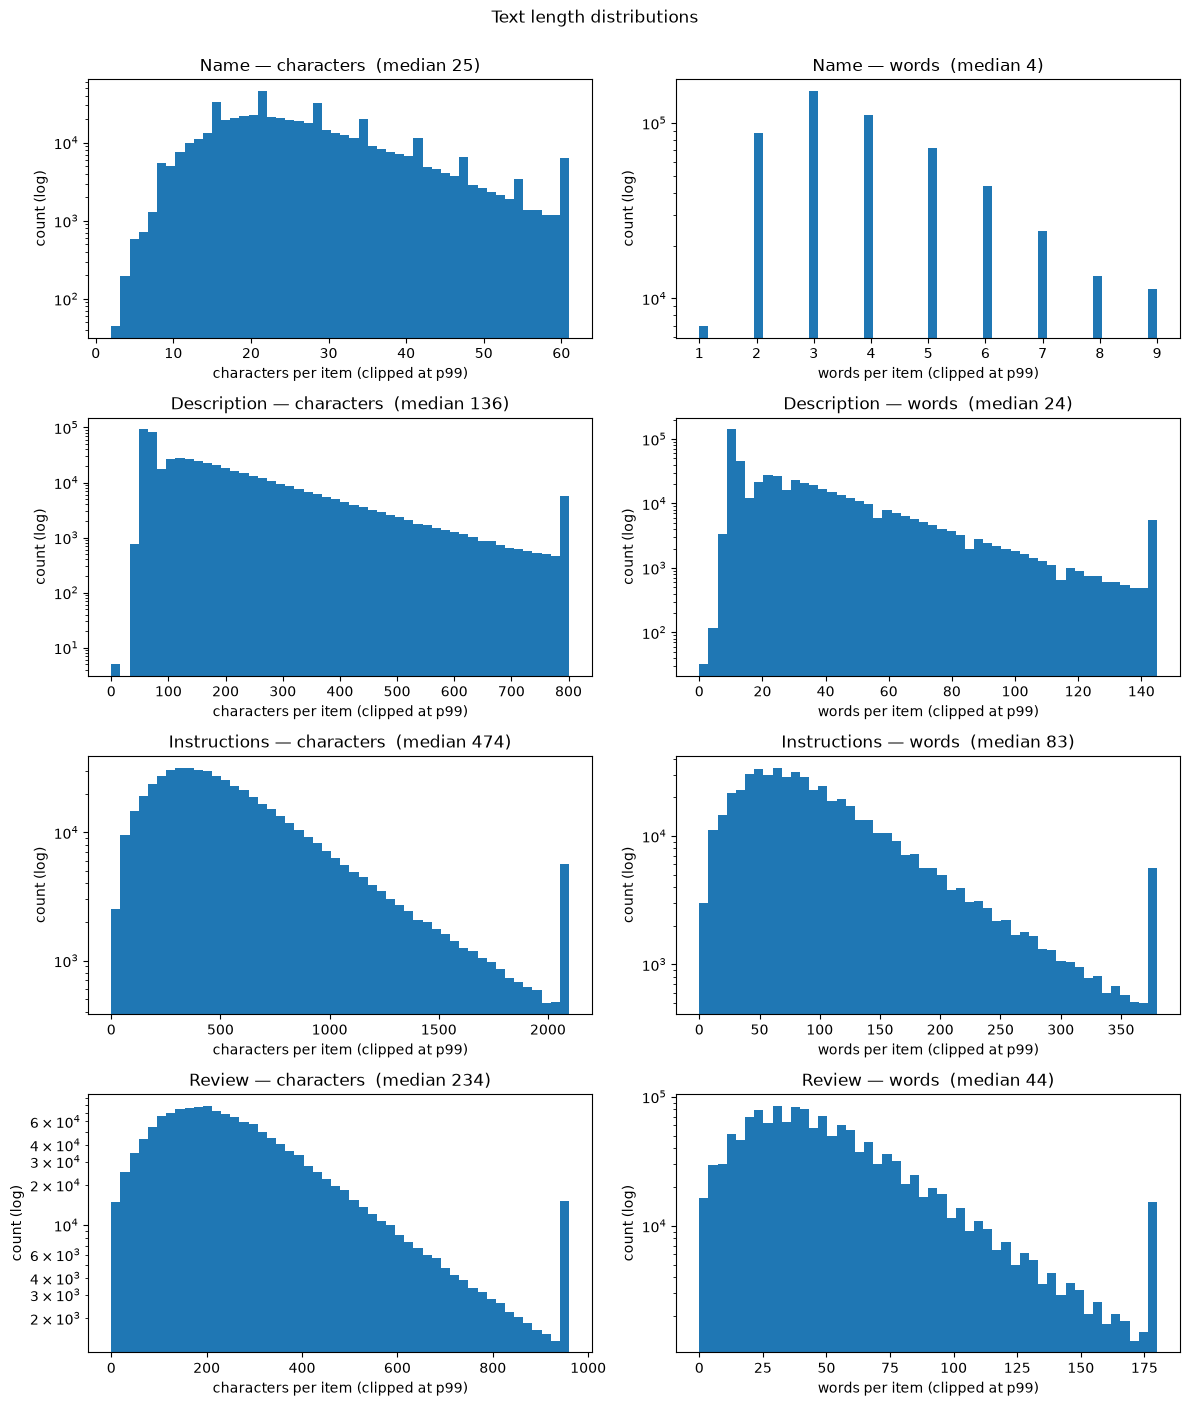

In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(12, 14))

for row, name in enumerate(text_fields):
    for col, (label, data) in enumerate(
        [("characters", char_len[name]), ("words", word_len[name])]
    ):
        ax = axes[row, col]
        hi = data.quantile(0.99)
        ax.hist(data.clip(upper=hi), bins=50)
        ax.set_yscale("log")
        ax.set_title(f"{name} \u2014 {label}  (median {data.median():.0f})")
        ax.set_xlabel(f"{label} per item (clipped at p99)")
        ax.set_ylabel("count (log)")

fig.suptitle("Text length distributions", y=1.001)
fig.tight_layout()

reviews total: 1,401,982  (median 44 words)
reviews with <= 1 words: 0.4%
reviews with <= 2 words: 0.8%
reviews with <= 3 words: 1.2%
reviews with <= 5 words: 2.1%


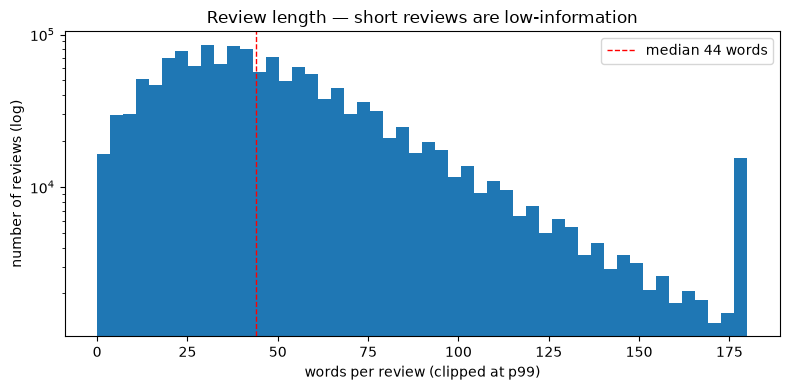

In [ ]:
rev_words = word_len["Review"].dropna()
print(f"reviews total: {len(rev_words):,}  (median {rev_words.median():.0f} words)")
for thr in (1, 2, 3, 5):
    print(f"reviews with <= {thr} words: {(rev_words <= thr).mean():.1%}")

hi = rev_words.quantile(0.99)
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(rev_words.clip(upper=hi), bins=50)
ax.set_yscale("log")
ax.axvline(rev_words.median(), color="r", ls="--", lw=1,
           label=f"median {rev_words.median():.0f} words")
ax.set_xlabel("words per review (clipped at p99)")
ax.set_ylabel("number of reviews (log)")
ax.set_title("Review length \u2014 short reviews are low-information")
ax.legend()
fig.tight_layout()

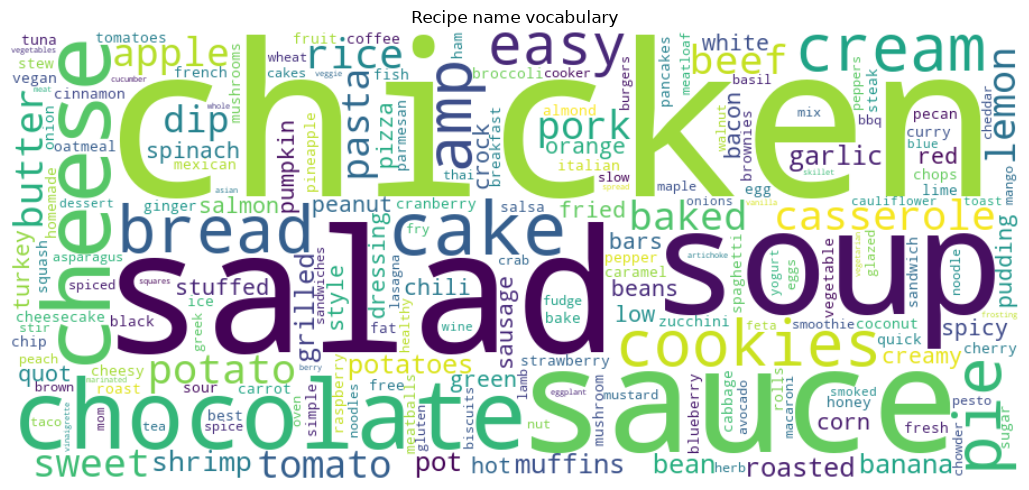

In [ ]:
import re
from collections import Counter

STOP = {
    "the", "and", "with", "for", "this", "that", "you", "your", "from", "out",
    "are", "was", "but", "not", "have", "had", "all", "any", "can", "will",
    "recipe", "made", "make", "used", "use", "very", "really", "just", "one",
}


def word_freq(series, min_len=3):
    counts = Counter()
    for txt in series.dropna():
        for w in re.findall(r"[a-z]+", txt.lower()):
            if len(w) >= min_len and w not in STOP:
                counts[w] += 1
    return counts


name_freq = word_freq(text_fields["Name"])

try:
    from wordcloud import WordCloud

    wc = WordCloud(width=900, height=400, background_color="white", colormap="viridis")
    wc.generate_from_frequencies(name_freq)
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title("Recipe name vocabulary")
    fig.tight_layout()
except ImportError:
    top = name_freq.most_common(20)
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh([w for w, _ in top][::-1], [c for _, c in top][::-1])
    ax.set_xlabel("count")
    ax.set_title("Top words in recipe names (install `wordcloud` for a cloud)")
    fig.tight_layout()

**Takeaways:** names and descriptions are short; instructions are longer but still
bounded — a whole recipe fits in one embedding, so **no chunking needed** (→ "1 recipe =
1 document" in notebook 2). Many reviews are 1–2 words ("Great recipe!"): low-information,
worth filtering before building an eval set.